In [10]:
import pandas as pd
import numpy as np
import random
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
base_dir = os.getcwd()
data_folder = os.path.join(base_dir, "data")


In [3]:
data_2022= pd.read_csv(os.path.join(data_folder, 'processed_22.csv'))
data_2023 = pd.read_csv(os.path.join(data_folder, 'processed_23.csv'))
data_2024 = pd.read_csv(os.path.join(data_folder, 'processed_24.csv'))
data_2025 = pd.read_csv(os.path.join(data_folder, 'processed_25.csv'))
total = pd.concat([data_2022, data_2023, data_2024, data_2025], ignore_index=True)  

In [ ]:
total = total.sort_values('date').reset_index(drop=True)
total['date'] = pd.to_datetime(total['date'])
total = total.set_index('date')

split_index = int(len(total) * 0.75)
train = total.iloc[:split_index]
test = total.iloc[split_index:]


In [ ]:
y_train = train['Lpoly_expected_ml']
y_test = test['Lpoly_expected_ml']


In [15]:
bare_baseline = y_train.iloc[-1]
baseline_preds = np.repeat(bare_baseline, len(y_test))

In [18]:
model = ARIMA(y_train, order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(y_test)) 

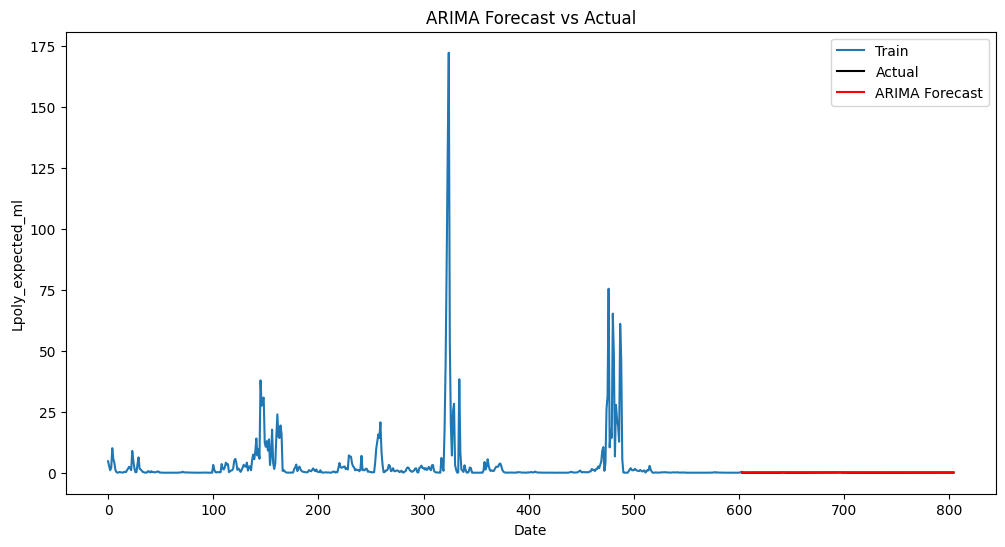

In [19]:
plt.figure(figsize=(12,6))

plt.plot(y_train.index, y_train, label='Train')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, forecast, label='ARIMA Forecast', color='red')

plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Lpoly_expected_ml')
plt.legend()
plt.show()

In [20]:
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mae = mean_absolute_error(y_test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.18893003030770886
MAE: 0.18788427636100585


In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y_train)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.165063164298931
p-value: 1.0356947479198967e-05
